# 6CS012 - Part II: Animals Image Classification

## Setup and Imports

In [1]:
import os
import time
import warnings
from pathlib import Path

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


I0000 00:00:1778348220.673848  656616 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778348220.757361  656616 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778348222.698175  656616 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU devices: []


E0000 00:00:1778348224.157610  656616 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Data Understanding, Analysis and Visualization

In [2]:
# Paths and basic constants
DATA_DIR = Path("final_dataset(128x128)")

SPLITS = ["train", "val", "test"]
IMG_SIZE = (128, 128)
INPUT_SHAPE = (128, 128, 3)
BATCH_SIZE = 16
SEED = 42

CLASS_NAMES = sorted([p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print("Dataset path:", DATA_DIR)
print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)
print("Final image size used by all models:", IMG_SIZE)


Dataset path: final_dataset(128x128)
Classes (10): ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Final image size used by all models: (128, 128)


In [3]:
# Count images in each split and class
counts = {}

for split in SPLITS:
    counts[split] = {}
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / split / class_name
        image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
        counts[split][class_name] = len(image_files)

count_table = pd.DataFrame(counts).rename_axis("Class")
count_table["Total"] = count_table.sum(axis=1)
count_table.loc["TOTAL"] = count_table.sum(axis=0)

display(count_table)
print("Total images:", int(count_table.loc["TOTAL", "Total"]))


,train,val,test,Total
Class,,,,
butterfly,1000,200,200,1400
cat,1000,200,200,1400
chicken,1000,200,200,1400
cow,1000,200,200,1400
dog,1000,200,200,1400
elephant,1000,200,200,1400
horse,1000,200,200,1400
sheep,1000,200,200,1400
spider,1000,200,200,1400


Total images: 14000


In [4]:
# Check whether any image is smaller than 128 x 128
small_images = []
min_width = 10**9
min_height = 10**9

for split in SPLITS:
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / split / class_name
        image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
        for image_path in image_files:
            with Image.open(image_path) as img:
                width, height = img.size
            min_width = min(min_width, width)
            min_height = min(min_height, height)
            if width < 128 or height < 128:
                small_images.append(str(image_path))

print("Minimum original width:", min_width)
print("Minimum original height:", min_height)
print("Images smaller than 128 x 128:", len(small_images))
print("Padding is enabled in the Keras image loader using pad_to_aspect_ratio=True.")


Minimum original width: 128
Minimum original height: 128
Images smaller than 128 x 128: 0
Padding is enabled in the Keras image loader using pad_to_aspect_ratio=True.


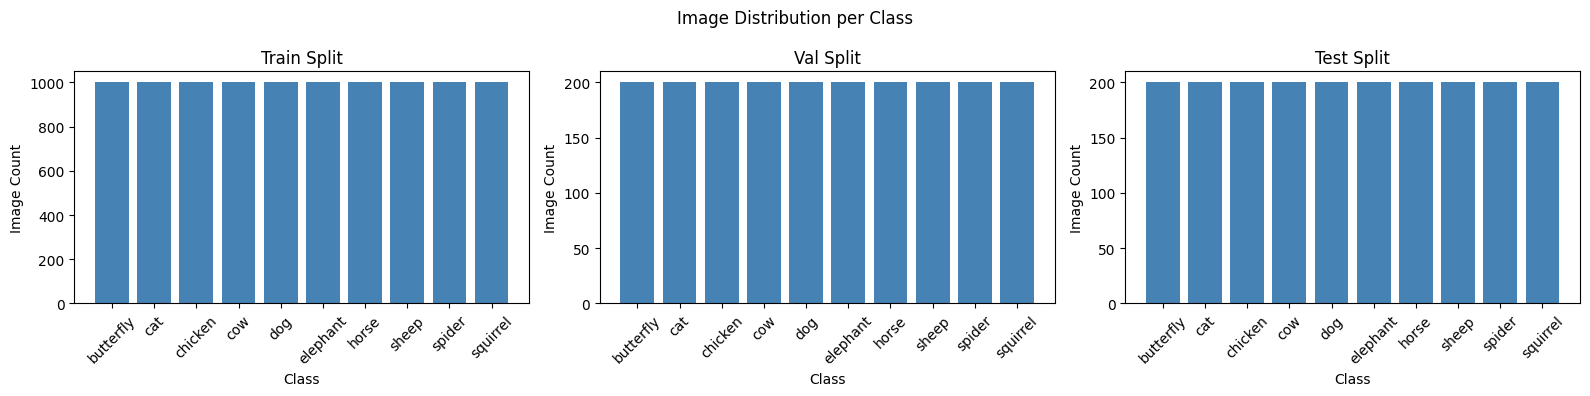

In [5]:
# Class distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, split in zip(axes, SPLITS):
    values = [counts[split][class_name] for class_name in CLASS_NAMES]
    ax.bar(CLASS_NAMES, values, color="steelblue")
    ax.set_title(f"{split.capitalize()} Split")
    ax.set_xlabel("Class")
    ax.set_ylabel("Image Count")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Image Distribution per Class")
plt.tight_layout()
plt.show()


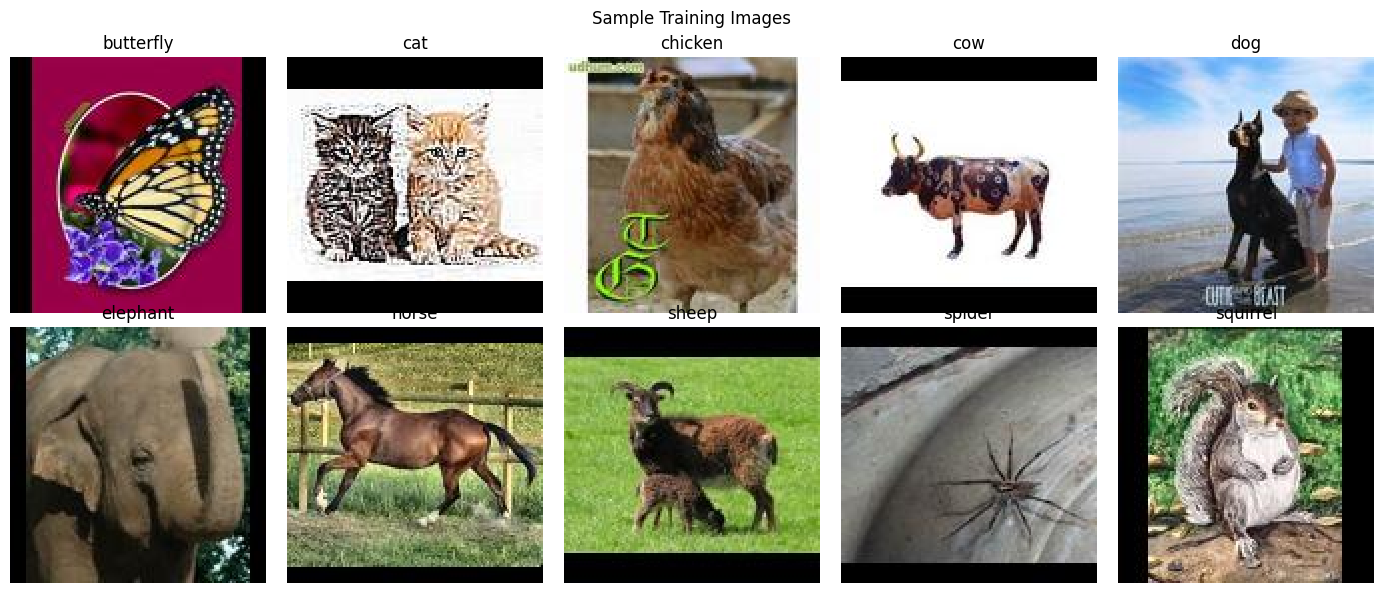

In [6]:
# Show one sample image from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / "train" / class_name
    image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
    img = Image.open(image_files[0]).convert("RGB")
    img = img.resize(IMG_SIZE)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


## Preprocessing and Dataset Loading

In [7]:
# Training dataset
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    pad_to_aspect_ratio=True,
)


Found 10000 files belonging to 10 classes.


In [8]:
# Validation dataset
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True,
)


Found 2000 files belonging to 10 classes.


In [9]:
# Test dataset
test_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True,
)


Found 2000 files belonging to 10 classes.


In [10]:
# Confirm batch shapes
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range before model rescaling:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)
Pixel value range before model rescaling: 0.0 to 255.0


### Data Augmentation

In [11]:
# Data augmentation layer
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(15 / 360),
        layers.RandomZoom(height_factor=(-0.2, 0.0), width_factor=(-0.2, 0.0)),
        layers.RandomBrightness(factor=0.2),
        layers.RandomContrast(factor=0.2),
    ],
    name="data_augmentation",
)


class RandomSaturation(layers.Layer):
    def __init__(self, factor=0.2, **kwargs):
        super().__init__(**kwargs)
        self.factor = factor

    def call(self, images, training=None):
        if training:
            return tf.image.random_saturation(
                images,
                lower=1.0 - self.factor,
                upper=1.0 + self.factor,
            )
        return images


class RandomErasing(layers.Layer):
    def __init__(self, probability=0.3, min_area=0.02, max_area=0.2, **kwargs):
        super().__init__(**kwargs)
        self.probability = probability
        self.min_area = min_area
        self.max_area = max_area

    def call(self, images, training=None):
        if not training:
            return images

        batch_size = tf.shape(images)[0]
        height = tf.shape(images)[1]
        width = tf.shape(images)[2]
        channels = tf.shape(images)[3]

        def erase_one(image):
            do_erase = tf.random.uniform([]) < self.probability

            erase_area = tf.random.uniform([], self.min_area, self.max_area)
            erase_h = tf.cast(tf.sqrt(erase_area) * tf.cast(height, tf.float32), tf.int32)
            erase_w = tf.cast(tf.sqrt(erase_area) * tf.cast(width, tf.float32), tf.int32)

            erase_h = tf.maximum(1, erase_h)
            erase_w = tf.maximum(1, erase_w)

            y = tf.random.uniform([], 0, height - erase_h + 1, dtype=tf.int32)
            x = tf.random.uniform([], 0, width - erase_w + 1, dtype=tf.int32)

            mask = tf.ones((erase_h, erase_w, channels), dtype=image.dtype)
            mask = tf.image.pad_to_bounding_box(mask, y, x, height, width)

            erased = image * (1 - mask)
            return tf.cond(do_erase, lambda: erased, lambda: image)

        return tf.map_fn(erase_one, images)


data_augmentation.add(RandomSaturation(0.2))
data_augmentation.add(RandomErasing(probability=0.3))


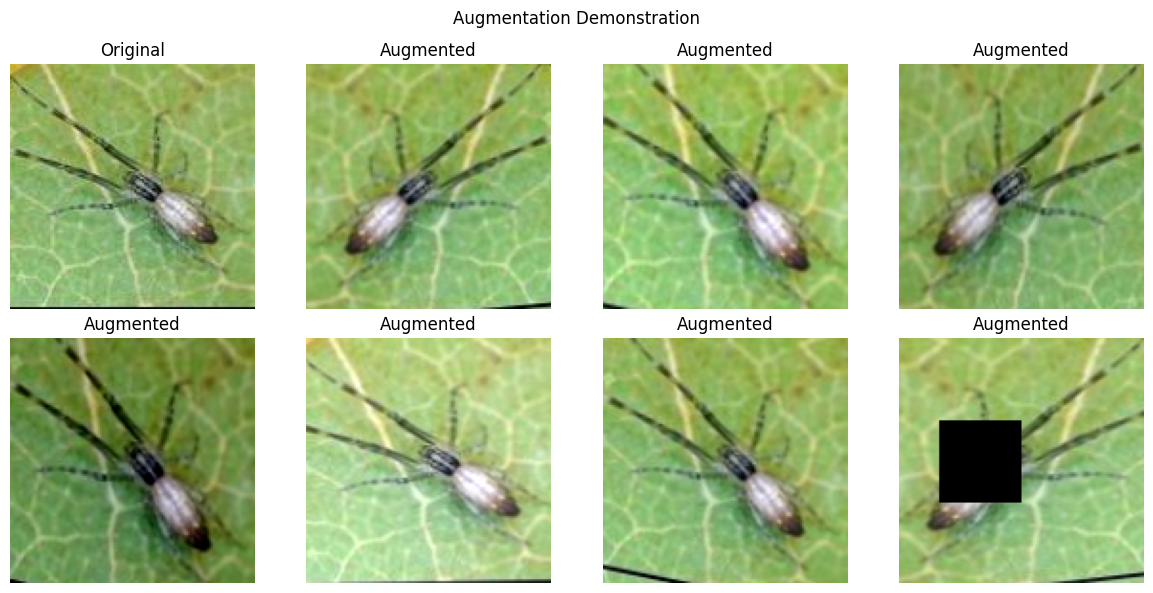

In [12]:
# augmentation image
for images, labels in train_ds.take(1):
    sample_image = images[0]
    break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

axes[0].imshow(sample_image.numpy().astype("uint8"))
axes[0].set_title("Original")
axes[0].axis("off")

for ax in axes[1:]:
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )[0]

    augmented_image = tf.clip_by_value(augmented_image, 0, 255)
    ax.imshow(augmented_image.numpy().astype("uint8"))
    ax.set_title("Augmented")
    ax.axis("off")

plt.suptitle("Augmentation Demonstration")
plt.tight_layout()
plt.show()

## Baseline CNN Model

In [13]:
# Build baseline CNN
baseline_model = models.Sequential(name="baseline_cnn")

baseline_model.add(layers.Input(shape=INPUT_SHAPE))
baseline_model.add(data_augmentation)
baseline_model.add(layers.Rescaling(1.0 / 255))

baseline_model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

baseline_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

baseline_model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

baseline_model.add(layers.Flatten())
baseline_model.add(layers.Dense(256, activation="relu"))
baseline_model.add(layers.Dense(128, activation="relu"))
baseline_model.add(layers.Dense(64, activation="relu"))
baseline_model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,914 (32.52 MB)

 Trainable params: 8,523,914 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile baseline CNN
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [15]:
# Train baseline CNN
t0_baseline = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1,
)

baseline_time = time.time() - t0_baseline
print(f"Baseline training time: {baseline_time / 60:.2f} minutes")


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 338ms/step - accuracy: 0.2824 - loss: 1.9914 - val_accuracy: 0.3560 - val_loss: 1.8779
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 334ms/step - accuracy: 0.4290 - loss: 1.6534 - val_accuracy: 0.4120 - val_loss: 1.7445
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 334ms/step - accuracy: 0.4955 - loss: 1.4597 - val_accuracy: 0.4975 - val_loss: 1.5447
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.5400 - loss: 1.3373 - val_accuracy: 0.5350 - val_loss: 1.3757
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 333ms/step - accuracy: 0.5790 - loss: 1.2247 - val_accuracy: 0.5570 - val_loss: 1.3254
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 333ms/step - accuracy: 0.6107 - loss: 1.1494 - val_accuracy: 0.5820 - val_loss: 1.2479
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 210s 336ms/step - accuracy: 0.6308 - loss: 1.0843 - val_accuracy: 0.5925 - val_loss: 1.2396
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.6595 -

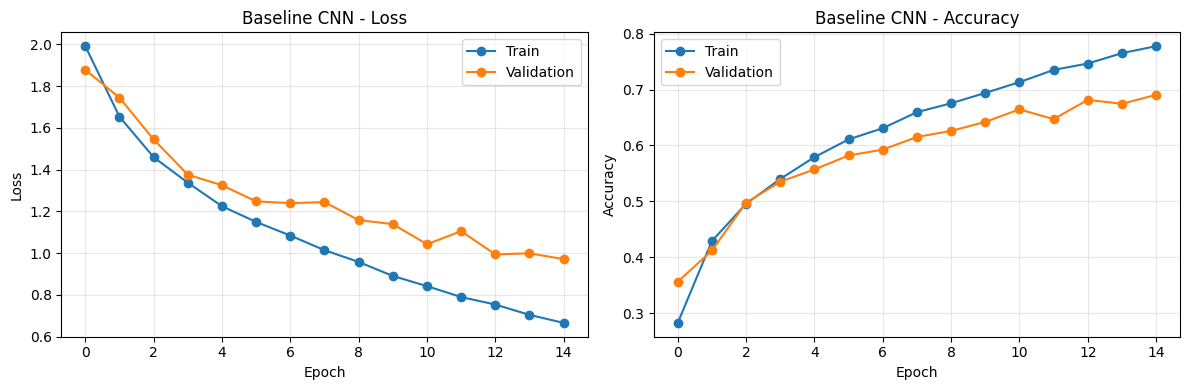

In [16]:
# Plot baseline training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history["loss"], marker="o", label="Train")
axes[0].plot(history_baseline.history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Baseline CNN - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history["accuracy"], marker="o", label="Train")
axes[1].plot(history_baseline.history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("Baseline CNN - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
# Evaluate baseline CNN
loss_b, acc_b = baseline_model.evaluate(test_ds, verbose=0)
print(f"Baseline test loss: {loss_b:.4f}")
print(f"Baseline test accuracy: {acc_b:.4f}")

y_true = np.concatenate([labels.numpy() for images, labels in test_ds], axis=0)
y_pred_b = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Baseline CNN")
print(classification_report(y_true, y_pred_b, target_names=CLASS_NAMES, digits=4))


Baseline test loss: 0.9126
Baseline test accuracy: 0.7070
Classification Report - Baseline CNN
              precision    recall  f1-score   support

   butterfly     0.7126    0.8800    0.7875       200
         cat     0.5955    0.7950    0.6809       200
     chicken     0.7269    0.8650    0.7900       200
         cow     0.7754    0.5350    0.6331       200
         dog     0.9273    0.2550    0.4000       200
    elephant     0.6667    0.7900    0.7231       200
       horse     0.7740    0.8050    0.7892       200
       sheep     0.6667    0.6900    0.6781       200
      spider     0.8281    0.7950    0.8112       200
    squirrel     0.6256    0.6600    0.6423       200

    accuracy                         0.7070      2000
   macro avg     0.7299    0.7070    0.6936      2000
weighted avg     0.7299    0.7070    0.6936      2000



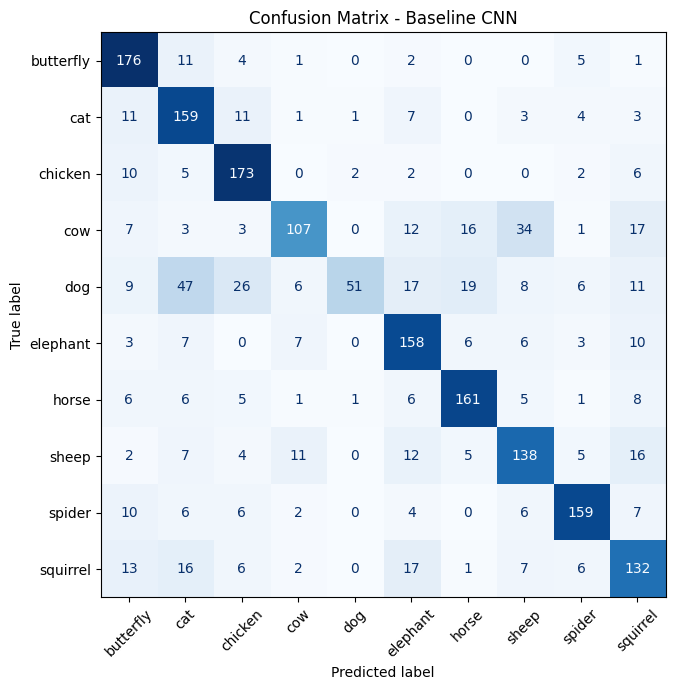

In [18]:
# Baseline confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_b),
    display_labels=CLASS_NAMES,
).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Baseline CNN")
plt.tight_layout()
plt.show()


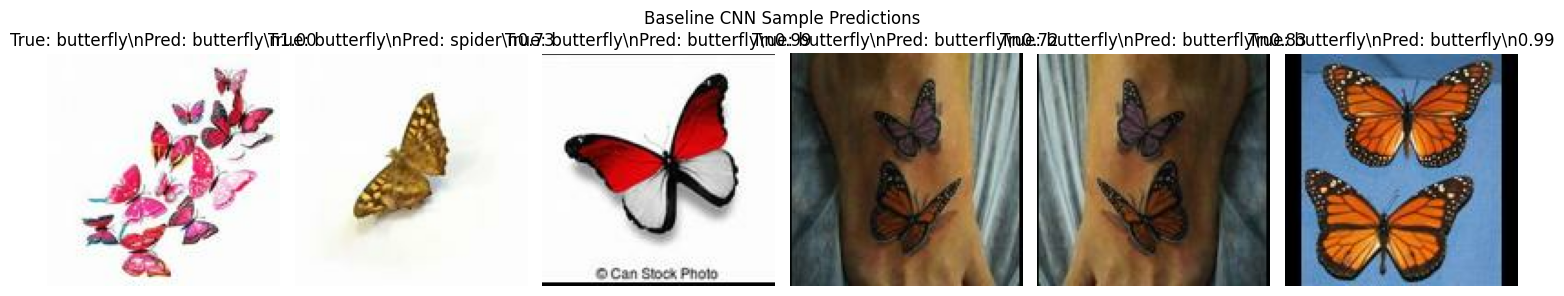

In [19]:
# Baseline inference on sample test images
for sample_images, sample_labels in test_ds.take(1):
    sample_probs = baseline_model.predict(sample_images, verbose=0)
    sample_preds = np.argmax(sample_probs, axis=1)
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].numpy().astype("uint8"))
    true_name = CLASS_NAMES[int(sample_labels[i])]
    pred_name = CLASS_NAMES[int(sample_preds[i])]
    confidence = float(sample_probs[i, sample_preds[i]])
    ax.set_title(f"True: {true_name}\\nPred: {pred_name}\\n{confidence:.2f}")
    ax.axis("off")

plt.suptitle("Baseline CNN Sample Predictions")
plt.tight_layout()
plt.show()


## Deeper CNN with Regularization

In [20]:
# Build deeper CNN with Adam
deeper_adam = models.Sequential(name="deeper_cnn_adam")

deeper_adam.add(layers.Input(shape=INPUT_SHAPE))
deeper_adam.add(data_augmentation)
deeper_adam.add(layers.Rescaling(1.0 / 255))

deeper_adam.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.MaxPooling2D((2, 2)))
deeper_adam.add(layers.Dropout(0.25))

deeper_adam.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.MaxPooling2D((2, 2)))
deeper_adam.add(layers.Dropout(0.25))

deeper_adam.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.MaxPooling2D((2, 2)))
deeper_adam.add(layers.Dropout(0.30))

deeper_adam.add(layers.Flatten())
deeper_adam.add(layers.Dense(512, activation="relu"))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Dropout(0.50))
deeper_adam.add(layers.Dense(256, activation="relu"))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Dropout(0.40))
deeper_adam.add(layers.Dense(128, activation="relu"))
deeper_adam.add(layers.Dropout(0.30))
deeper_adam.add(layers.Dense(NUM_CLASSES, activation="softmax"))

deeper_adam.summary()


Model: "deeper_cnn_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,234,666 (65.75 MB)

 Trainable params: 17,232,234 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [21]:
# Compile deeper CNN with Adam
deeper_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [22]:
# Train deeper CNN with Adam
t0_deeper_adam = time.time()

history_deeper_adam = deeper_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)

deeper_adam_time = time.time() - t0_deeper_adam
print(f"Deeper CNN Adam training time: {deeper_adam_time / 60:.2f} minutes")


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 860s 1s/step - accuracy: 0.1784 - loss: 2.7446 - val_accuracy: 0.2205 - val_loss: 2.2540
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 842s 1s/step - accuracy: 0.2340 - loss: 2.3880 - val_accuracy: 0.2605 - val_loss: 2.1188
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 836s 1s/step - accuracy: 0.2737 - loss: 2.2050 - val_accuracy: 0.3350 - val_loss: 1.9216
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 833s 1s/step - accuracy: 0.3059 - loss: 2.0659 - val_accuracy: 0.3985 - val_loss: 1.7262
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 835s 1s/step - accuracy: 0.3356 - loss: 1.9627 - val_accuracy: 0.4045 - val_loss: 1.6947
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 834s 1s/step - accuracy: 0.3519 - loss: 1.8832 - val_accuracy: 0.4110 - val_loss: 1.6770
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 837s 1s/step - accuracy: 0.3814 - loss: 1.8180 - val_accuracy: 0.3975 - val_loss: 1.7310
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 826s 1s/step - accuracy: 0.4026 - loss: 1.7416 - val_accu

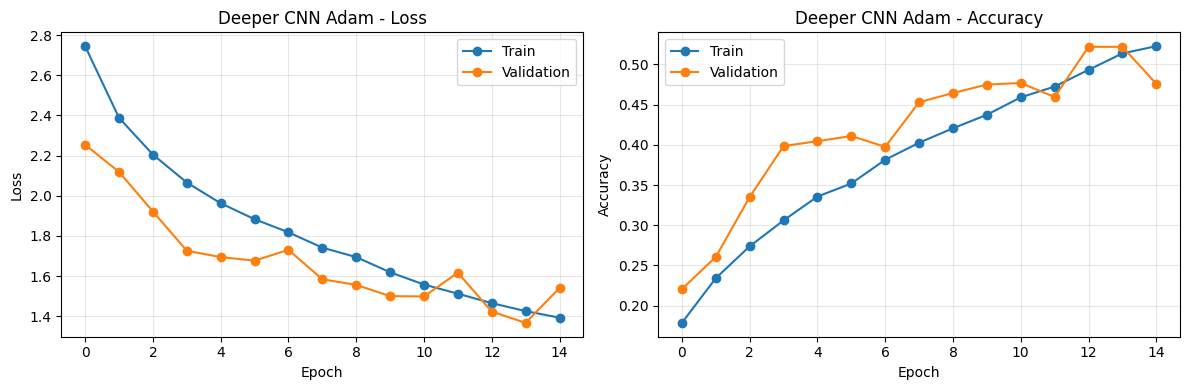

In [23]:
# Plot deeper Adam training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_deeper_adam.history["loss"], marker="o", label="Train")
axes[0].plot(history_deeper_adam.history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Deeper CNN Adam - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history["accuracy"], marker="o", label="Train")
axes[1].plot(history_deeper_adam.history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("Deeper CNN Adam - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [24]:
# Evaluate deeper CNN with Adam
loss_da, acc_da = deeper_adam.evaluate(test_ds, verbose=0)
print(f"Deeper Adam test loss: {loss_da:.4f}")
print(f"Deeper Adam test accuracy: {acc_da:.4f}")

y_pred_da = np.argmax(deeper_adam.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Deeper CNN Adam")
print(classification_report(y_true, y_pred_da, target_names=CLASS_NAMES, digits=4))


Deeper Adam test loss: 1.3714
Deeper Adam test accuracy: 0.5055
Classification Report - Deeper CNN Adam
              precision    recall  f1-score   support

   butterfly     0.9231    0.4800    0.6316       200
         cat     0.5208    0.2500    0.3378       200
     chicken     0.5318    0.8350    0.6498       200
         cow     0.6667    0.1300    0.2176       200
         dog     0.8254    0.2600    0.3954       200
    elephant     0.5522    0.5550    0.5536       200
       horse     0.5661    0.6850    0.6199       200
       sheep     0.3031    0.7700    0.4350       200
      spider     0.6019    0.6350    0.6180       200
    squirrel     0.4099    0.4550    0.4313       200

    accuracy                         0.5055      2000
   macro avg     0.5901    0.5055    0.4890      2000
weighted avg     0.5901    0.5055    0.4890      2000



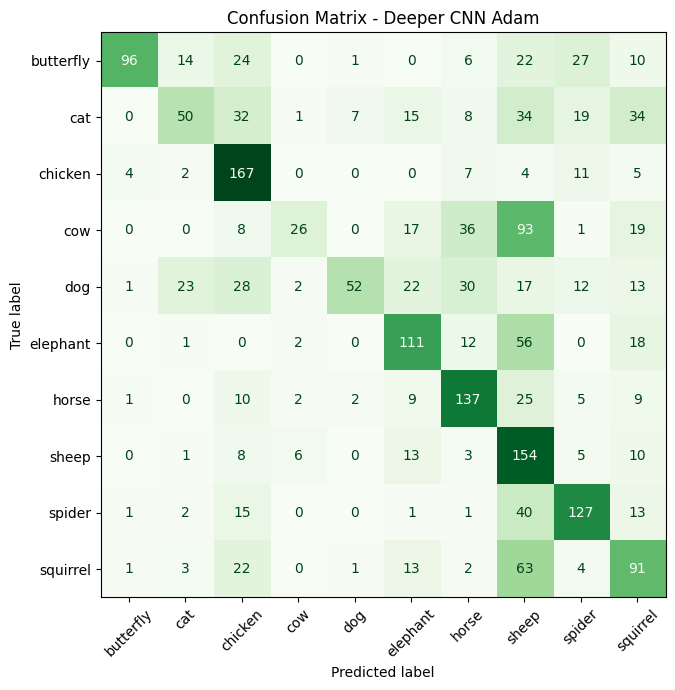

In [25]:
# Deeper Adam confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_da),
    display_labels=CLASS_NAMES,
).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Deeper CNN Adam")
plt.tight_layout()
plt.show()


## Optimizer Analysis: SGD vs Adam

In [26]:
# Build deeper CNN with SGD
deeper_sgd = models.Sequential(name="deeper_cnn_sgd")

deeper_sgd.add(layers.Input(shape=INPUT_SHAPE))
deeper_sgd.add(data_augmentation)
deeper_sgd.add(layers.Rescaling(1.0 / 255))

deeper_sgd.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.MaxPooling2D((2, 2)))
deeper_sgd.add(layers.Dropout(0.25))

deeper_sgd.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.MaxPooling2D((2, 2)))
deeper_sgd.add(layers.Dropout(0.25))

deeper_sgd.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.MaxPooling2D((2, 2)))
deeper_sgd.add(layers.Dropout(0.30))

deeper_sgd.add(layers.Flatten())
deeper_sgd.add(layers.Dense(512, activation="relu"))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Dropout(0.50))
deeper_sgd.add(layers.Dense(256, activation="relu"))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Dropout(0.40))
deeper_sgd.add(layers.Dense(128, activation="relu"))
deeper_sgd.add(layers.Dropout(0.30))
deeper_sgd.add(layers.Dense(NUM_CLASSES, activation="softmax"))

deeper_sgd.summary()


Model: "deeper_cnn_sgd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,234,666 (65.75 MB)

 Trainable params: 17,232,234 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [27]:
# Compile deeper CNN with SGD
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [28]:
# Train deeper CNN with SGD
t0_deeper_sgd = time.time()

history_deeper_sgd = deeper_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)

deeper_sgd_time = time.time() - t0_deeper_sgd
print(f"Deeper CNN SGD training time: {deeper_sgd_time / 60:.2f} minutes")


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 750s 1s/step - accuracy: 0.1598 - loss: 2.4227 - val_accuracy: 0.2200 - val_loss: 2.0882
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.2260 - loss: 2.1578 - val_accuracy: 0.1820 - val_loss: 2.3083
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 747s 1s/step - accuracy: 0.2585 - loss: 2.0655 - val_accuracy: 0.2925 - val_loss: 1.9966
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.3078 - loss: 1.9548 - val_accuracy: 0.3250 - val_loss: 1.8686
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.3368 - loss: 1.8825 - val_accuracy: 0.3680 - val_loss: 1.7632
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 748s 1s/step - accuracy: 0.3644 - loss: 1.8111 - val_accuracy: 0.4090 - val_loss: 1.6731
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 752s 1s/step - accuracy: 0.3844 - loss: 1.7601 - val_accuracy: 0.3965 - val_loss: 1.6801
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 745s 1s/step - accuracy: 0.4061 - loss: 1.6930 - val_accu

In [29]:
# Evaluate deeper CNN with SGD
loss_ds, acc_ds = deeper_sgd.evaluate(test_ds, verbose=0)
print(f"Deeper SGD test loss: {loss_ds:.4f}")
print(f"Deeper SGD test accuracy: {acc_ds:.4f}")

y_pred_ds = np.argmax(deeper_sgd.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Deeper CNN SGD")
print(classification_report(y_true, y_pred_ds, target_names=CLASS_NAMES, digits=4))


Deeper SGD test loss: 1.0812
Deeper SGD test accuracy: 0.6280
Classification Report - Deeper CNN SGD
              precision    recall  f1-score   support

   butterfly     0.7989    0.7350    0.7656       200
         cat     0.6158    0.5450    0.5782       200
     chicken     0.8693    0.7650    0.8138       200
         cow     0.5373    0.3600    0.4311       200
         dog     0.7114    0.5300    0.6074       200
    elephant     0.6897    0.6000    0.6417       200
       horse     0.6588    0.5600    0.6054       200
       sheep     0.4916    0.7350    0.5892       200
      spider     0.6904    0.8250    0.7517       200
    squirrel     0.4195    0.6250    0.5020       200

    accuracy                         0.6280      2000
   macro avg     0.6483    0.6280    0.6286      2000
weighted avg     0.6483    0.6280    0.6286      2000



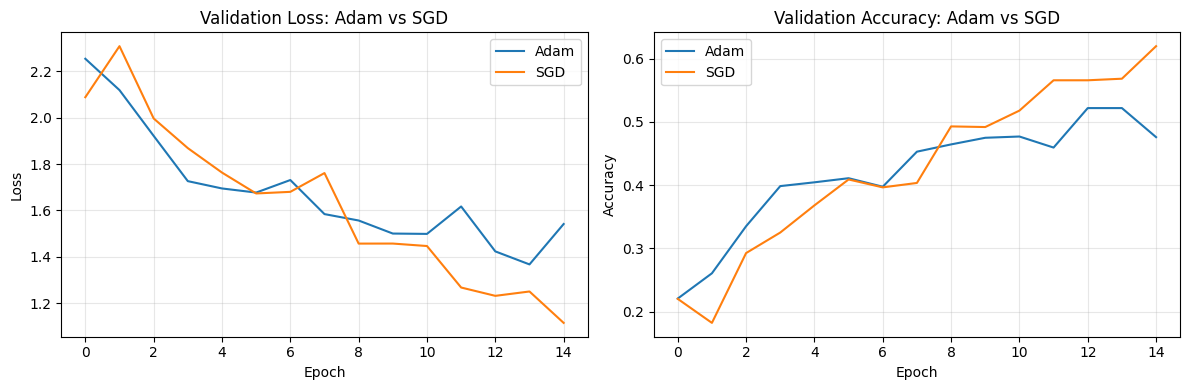

In [30]:
# Adam vs SGD validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_deeper_adam.history["val_loss"], label="Adam")
axes[0].plot(history_deeper_sgd.history["val_loss"], label="SGD")
axes[0].set_title("Validation Loss: Adam vs SGD")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history["val_accuracy"], label="Adam")
axes[1].plot(history_deeper_sgd.history["val_accuracy"], label="SGD")
axes[1].set_title("Validation Accuracy: Adam vs SGD")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Ablation Study: Removing Dropout

In [31]:
# Build deeper CNN without Dropout
no_dropout = models.Sequential(name="deeper_cnn_no_dropout")

no_dropout.add(layers.Input(shape=INPUT_SHAPE))
no_dropout.add(data_augmentation)
no_dropout.add(layers.Rescaling(1.0 / 255))

no_dropout.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.MaxPooling2D((2, 2)))

no_dropout.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.MaxPooling2D((2, 2)))

no_dropout.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.MaxPooling2D((2, 2)))

no_dropout.add(layers.Flatten())
no_dropout.add(layers.Dense(512, activation="relu"))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Dense(256, activation="relu"))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Dense(128, activation="relu"))
no_dropout.add(layers.Dense(NUM_CLASSES, activation="softmax"))

no_dropout.summary()


Model: "deeper_cnn_no_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 32, 32, 128)    │             

 Total params: 17,234,666 (65.75 MB)

 Trainable params: 17,232,234 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [32]:
# Compile and train no-dropout model
no_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

t0_no_dropout = time.time()

history_no_dropout = no_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1,
)

no_dropout_time = time.time() - t0_no_dropout
print(f"No-dropout training time: {no_dropout_time / 60:.2f} minutes")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 791s 1s/step - accuracy: 0.3822 - loss: 1.7897 - val_accuracy: 0.4450 - val_loss: 1.5883
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4289s 7s/step - accuracy: 0.5288 - loss: 1.3698 - val_accuracy: 0.5255 - val_loss: 1.4696
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 822s 1s/step - accuracy: 0.6044 - loss: 1.1625 - val_accuracy: 0.5355 - val_loss: 1.4395
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 820s 1s/step - accuracy: 0.6484 - loss: 1.0285 - val_accuracy: 0.5835 - val_loss: 1.2042
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 805s 1s/step - accuracy: 0.6923 - loss: 0.9067 - val_accuracy: 0.6355 - val_loss: 1.0996
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 821s 1s/step - accuracy: 0.7186 - loss: 0.8300 - val_accuracy: 0.6520 - val_loss: 1.0279
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 836s 1s/step - accuracy: 0.7504 - loss: 0.7524 - val_accuracy: 0.7005 - val_loss: 0.9016
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.7745 - loss: 0.6899 - val_acc

In [33]:
# Evaluate no-dropout model
loss_nd, acc_nd = no_dropout.evaluate(test_ds, verbose=0)
print(f"No-dropout test loss: {loss_nd:.4f}")
print(f"No-dropout test accuracy: {acc_nd:.4f}")

y_pred_nd = np.argmax(no_dropout.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Deeper CNN without Dropout")
print(classification_report(y_true, y_pred_nd, target_names=CLASS_NAMES, digits=4))


No-dropout test loss: 0.7199
No-dropout test accuracy: 0.7590
Classification Report - Deeper CNN without Dropout
              precision    recall  f1-score   support

   butterfly     0.8796    0.8400    0.8593       200
         cat     0.8239    0.6550    0.7298       200
     chicken     0.8119    0.8850    0.8469       200
         cow     0.7429    0.6500    0.6933       200
         dog     0.8603    0.5850    0.6964       200
    elephant     0.8287    0.7500    0.7874       200
       horse     0.8263    0.7850    0.8051       200
       sheep     0.5282    0.8900    0.6629       200
      spider     0.7847    0.8200    0.8020       200
    squirrel     0.7157    0.7300    0.7228       200

    accuracy                         0.7590      2000
   macro avg     0.7802    0.7590    0.7606      2000
weighted avg     0.7802    0.7590    0.7606      2000



## Comparative Analysis of Scratch Models

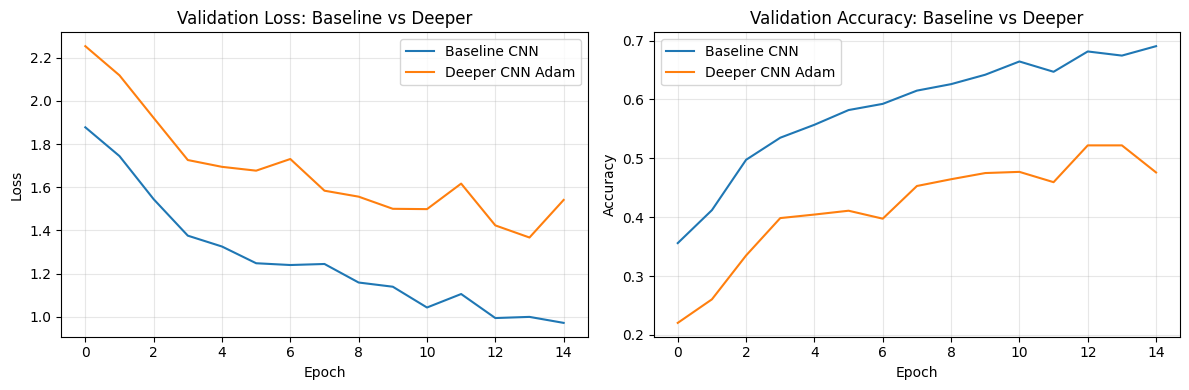

In [34]:
# Baseline vs deeper validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history["val_loss"], label="Baseline CNN")
axes[0].plot(history_deeper_adam.history["val_loss"], label="Deeper CNN Adam")
axes[0].set_title("Validation Loss: Baseline vs Deeper")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history["val_accuracy"], label="Baseline CNN")
axes[1].plot(history_deeper_adam.history["val_accuracy"], label="Deeper CNN Adam")
axes[1].set_title("Validation Accuracy: Baseline vs Deeper")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
# Scratch model comparison table
scratch_results = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN Adam", "Deeper CNN SGD", "No Dropout"],
    "Test Accuracy": [acc_b, acc_da, acc_ds, acc_nd],
    "Test Loss": [loss_b, loss_da, loss_ds, loss_nd],
    "Training Time (min)": [baseline_time / 60, deeper_adam_time / 60, deeper_sgd_time / 60, no_dropout_time / 60],
})

display(scratch_results)


,Model,Test Accuracy,Test Loss,Training Time (min)
0,Baseline CNN,0.7070,0.912634,54.124344
1,Deeper CNN Adam,0.5055,1.371362,208.301441
2,Deeper CNN SGD,0.6280,1.081163,188.571710
3,No Dropout,0.7590,0.719871,195.620339


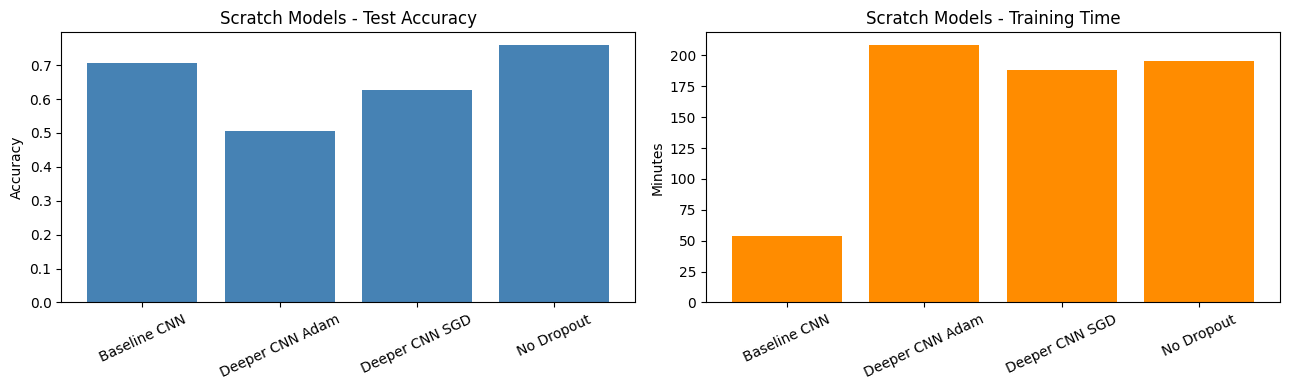

In [36]:
# Scratch model comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(scratch_results["Model"], scratch_results["Test Accuracy"], color="steelblue")
axes[0].set_title("Scratch Models - Test Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(scratch_results["Model"], scratch_results["Training Time (min)"], color="darkorange")
axes[1].set_title("Scratch Models - Training Time")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## Transfer Learning with ResNet50

In [37]:
# Load pretrained ResNet50 convolutional base
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE,
)

resnet_base.trainable = False
print("ResNet50 base loaded. Trainable:", resnet_base.trainable)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
ResNet50 base loaded. Trainable: False


In [38]:
# Build transfer learning model
resnet_model = models.Sequential(name="resnet50_transfer_learning")

resnet_model.add(layers.Input(shape=INPUT_SHAPE))
resnet_model.add(layers.Lambda(resnet_preprocess))
resnet_model.add(resnet_base)
resnet_model.add(layers.GlobalAveragePooling2D())
resnet_model.add(layers.Dense(256, activation="relu"))
resnet_model.add(layers.Dropout(0.50))
resnet_model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

resnet_model.summary()


Model: "resnet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [39]:
# Compile transfer learning model for feature extraction
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [40]:
# Train only the new classifier head
t0_resnet_head = time.time()

history_resnet_head = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1,
)

resnet_head_time = time.time() - t0_resnet_head
print(f"ResNet50 feature extraction time: {resnet_head_time / 60:.2f} minutes")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 489ms/step - accuracy: 0.6993 - loss: 0.9503 - val_accuracy: 0.8855 - val_loss: 0.3478
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 424ms/step - accuracy: 0.8719 - loss: 0.3868 - val_accuracy: 0.9175 - val_loss: 0.2556
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 423ms/step - accuracy: 0.9126 - loss: 0.2698 - val_accuracy: 0.9320 - val_loss: 0.2065
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 303s 484ms/step - accuracy: 0.9320 - loss: 0.2098 - val_accuracy: 0.9465 - val_loss: 0.1716
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 266s 426ms/step - accuracy: 0.9493 - loss: 0.1617 - val_accuracy: 0.9540 - val_loss: 0.1474
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 273s 436ms/step - accuracy: 0.9604 - loss: 0.1307 - val_accuracy: 0.9575 - val_loss: 0.1310
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 278s 444ms/step - accuracy: 0.9679 - loss: 0.1010 - val_accuracy: 0.9625 - val_loss: 0.1163
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 315s 434ms/step - accuracy: 0.9735 -

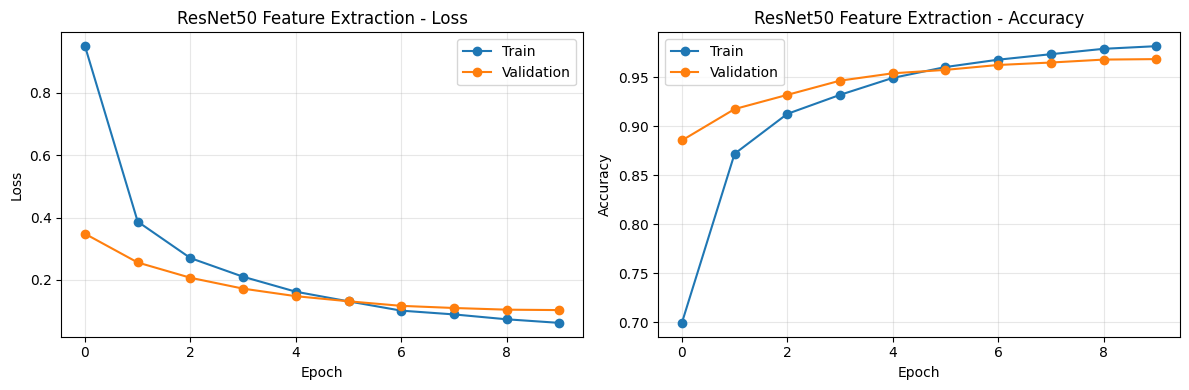

In [41]:
# Plot feature extraction curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_resnet_head.history["loss"], marker="o", label="Train")
axes[0].plot(history_resnet_head.history["val_loss"], marker="o", label="Validation")
axes[0].set_title("ResNet50 Feature Extraction - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_resnet_head.history["accuracy"], marker="o", label="Train")
axes[1].plot(history_resnet_head.history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("ResNet50 Feature Extraction - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Fine-tuning

In [42]:
# Unfreeze only the last ResNet block
resnet_base.trainable = True

for layer in resnet_base.layers:
    layer.trainable = layer.name.startswith("conv5")

trainable_layers = sum([1 for layer in resnet_base.layers if layer.trainable])
print("Trainable layers in ResNet50 base:", trainable_layers)


Trainable layers in ResNet50 base: 32


In [43]:
# Compile model for fine-tuning
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [44]:
# Fine-tune ResNet50
t0_resnet_fine = time.time()

history_resnet_fine = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1,
)

resnet_fine_time = time.time() - t0_resnet_fine
resnet_total_time = resnet_head_time + resnet_fine_time
print(f"ResNet50 fine-tuning time: {resnet_fine_time / 60:.2f} minutes")
print(f"ResNet50 total training time: {resnet_total_time / 60:.2f} minutes")


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 503s 786ms/step - accuracy: 0.9278 - loss: 0.2293 - val_accuracy: 0.9660 - val_loss: 0.1241
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 487s 762ms/step - accuracy: 0.9627 - loss: 0.1203 - val_accuracy: 0.9710 - val_loss: 0.0891
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 449s 718ms/step - accuracy: 0.9798 - loss: 0.0743 - val_accuracy: 0.9745 - val_loss: 0.0846
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 428s 686ms/step - accuracy: 0.9878 - loss: 0.0498 - val_accuracy: 0.9785 - val_loss: 0.0718
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 454s 705ms/step - accuracy: 0.9907 - loss: 0.0372 - val_accuracy: 0.9775 - val_loss: 0.0728
ResNet50 fine-tuning time: 38.68 minutes
ResNet50 total training time: 88.28 minutes


In [45]:
# Evaluate ResNet50 transfer learning model
loss_rn, acc_rn = resnet_model.evaluate(test_ds, verbose=0)
print(f"ResNet50 test loss: {loss_rn:.4f}")
print(f"ResNet50 test accuracy: {acc_rn:.4f}")

y_pred_rn = np.argmax(resnet_model.predict(test_ds, verbose=0), axis=1)

print("Classification Report - ResNet50 Transfer Learning")
print(classification_report(y_true, y_pred_rn, target_names=CLASS_NAMES, digits=4))


ResNet50 test loss: 0.0689
ResNet50 test accuracy: 0.9770
Classification Report - ResNet50 Transfer Learning
              precision    recall  f1-score   support

   butterfly     0.9852    1.0000    0.9926       200
         cat     0.9803    0.9950    0.9876       200
     chicken     0.9949    0.9850    0.9899       200
         cow     0.9643    0.9450    0.9545       200
         dog     0.9949    0.9800    0.9874       200
    elephant     0.9703    0.9800    0.9751       200
       horse     0.9479    1.0000    0.9732       200
       sheep     0.9590    0.9350    0.9468       200
      spider     1.0000    0.9850    0.9924       200
    squirrel     0.9747    0.9650    0.9698       200

    accuracy                         0.9770      2000
   macro avg     0.9772    0.9770    0.9770      2000
weighted avg     0.9772    0.9770    0.9770      2000



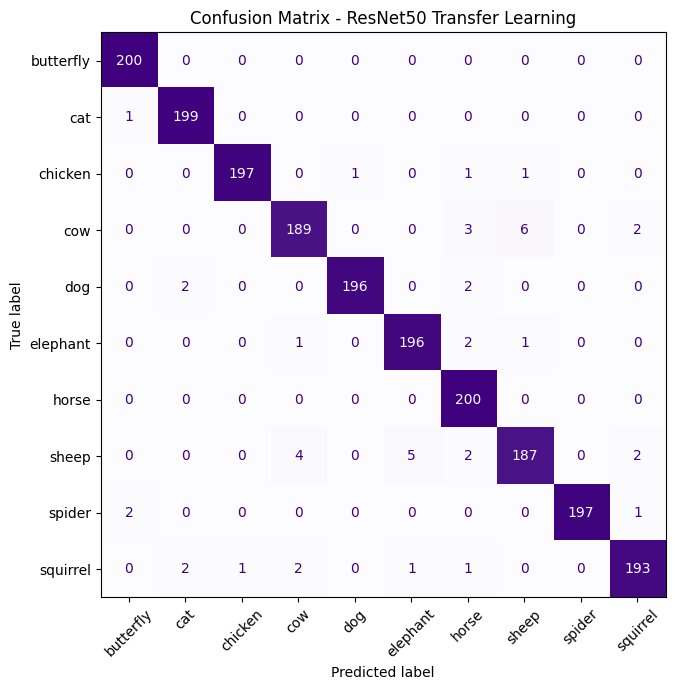

In [46]:
# ResNet50 confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_rn),
    display_labels=CLASS_NAMES,
).plot(ax=ax, cmap="Purples", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - ResNet50 Transfer Learning")
plt.tight_layout()
plt.show()


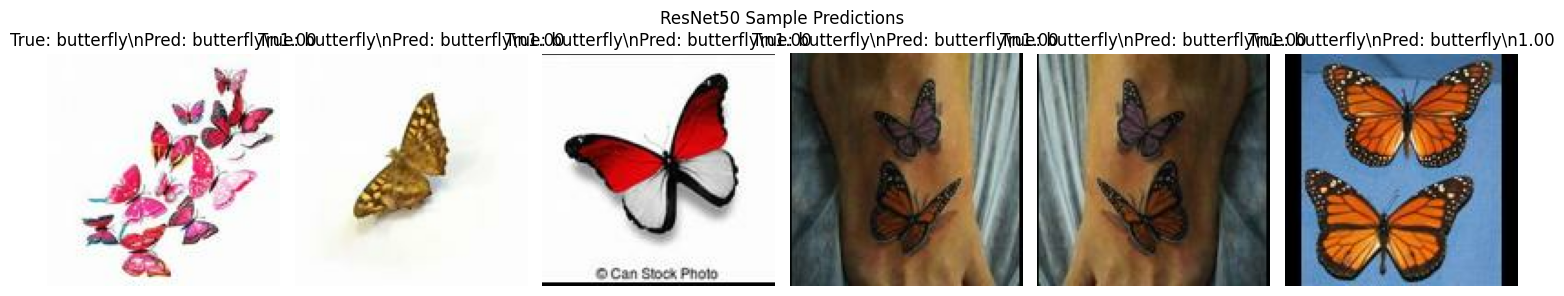

In [47]:
# ResNet50 sample predictions
for sample_images, sample_labels in test_ds.take(1):
    sample_probs = resnet_model.predict(sample_images, verbose=0)
    sample_preds = np.argmax(sample_probs, axis=1)
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].numpy().astype("uint8"))
    true_name = CLASS_NAMES[int(sample_labels[i])]
    pred_name = CLASS_NAMES[int(sample_preds[i])]
    confidence = float(sample_probs[i, sample_preds[i]])
    ax.set_title(f"True: {true_name}\\nPred: {pred_name}\\n{confidence:.2f}")
    ax.axis("off")

plt.suptitle("ResNet50 Sample Predictions")
plt.tight_layout()
plt.show()


## Final Model Comparison

In [48]:
# Final comparison table
final_results = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN Adam", "Deeper CNN SGD", "ResNet50 Transfer Learning"],
    "Test Accuracy": [acc_b, acc_da, acc_ds, acc_rn],
    "Test Loss": [loss_b, loss_da, loss_ds, loss_rn],
    "Training Time (min)": [baseline_time / 60, deeper_adam_time / 60, deeper_sgd_time / 60, resnet_total_time / 60],
})

display(final_results)


,Model,Test Accuracy,Test Loss,Training Time (min)
0,Baseline CNN,0.7070,0.912634,54.124344
1,Deeper CNN Adam,0.5055,1.371362,208.301441
2,Deeper CNN SGD,0.6280,1.081163,188.571710
3,ResNet50 Transfer Learning,0.9770,0.068894,88.281102


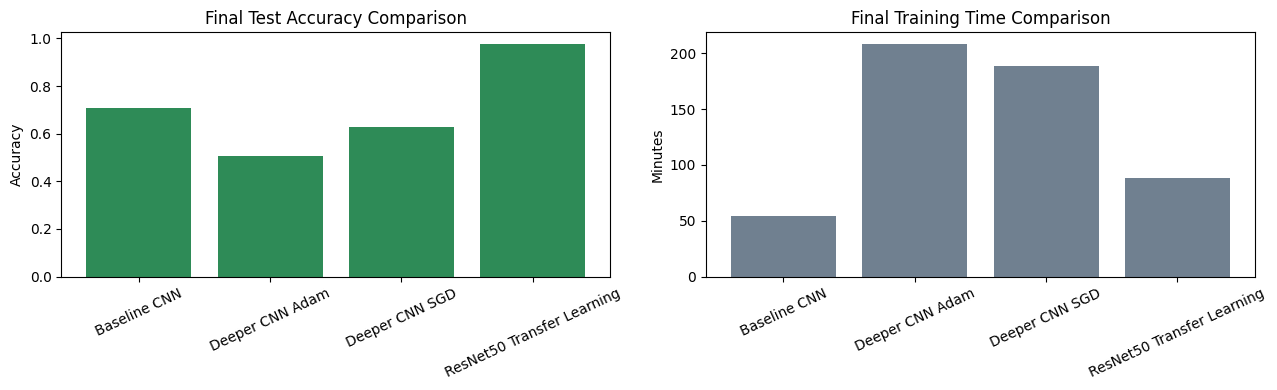

In [49]:
# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(final_results["Model"], final_results["Test Accuracy"], color="seagreen")
axes[0].set_title("Final Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(final_results["Model"], final_results["Training Time (min)"], color="slategray")
axes[1].set_title("Final Training Time Comparison")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
